# Questão 7 — Previsão de Demanda

## Objetivo

Construir um modelo baseline simples para prever a demanda diária do produto **Motor de Popa Yamaha Evo Dash 155HP** durante o mês de Janeiro de 2024.

## Contexto de negócio

A empresa precisa reduzir decisões baseadas em feeling e passar a apoiar o planejamento de compras com uma previsão objetiva de demanda.

## Abordagem

Será utilizado um baseline de **média móvel de 7 dias**, calculado apenas com dados históricos disponíveis até a data da previsão, evitando vazamento de informação.

## Fonte de dados

A análise será feita sobre a camada gold do projeto, utilizando:

- `lh_nautical.04_gold.fct_vendas`
- `lh_nautical.04_gold.dim_produto`



In [0]:
# Importação das bibliotecas necessárias para manipulação de dados
import pandas as pd
import numpy as np

# Leitura das tabelas
df_vendas = spark.table("lh_nautical.04_gold.fct_vendas")
df_produtos = spark.table("lh_nautical.04_gold.dim_produto")

# Conversão para pandas para facilitar a construção do baseline temporal
pdf_vendas = df_vendas.toPandas()
pdf_produtos = df_produtos.toPandas()

# Garantia do tipo correto da coluna de data
pdf_vendas["sale_date"] = pd.to_datetime(pdf_vendas["sale_date"])

In [0]:
# Junção entre fato de vendas e dimensão de produto
# Necessária porque o nome do produto está na dim_produto, não na fato
df_base = pdf_vendas.merge(
    pdf_produtos[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

# Conferência inicial da base analítica
df_base.head()

,sale_id,customer_id,product_id,sale_date,quantity,receita_transacao_brl,custo_unitario_brl,custo_total_brl,prejuizo_brl,teve_prejuizo,cost_start_date,exchange_rate_date,exchange_rate,product_name
0,0,42,105,2023-09-10,11,3405.00,312.17,3433.83,28.83,True,2023-04-17,2023-09-08,4.983500,Cabo de Nylon Danforth Prime
1,1,3,136,2024-09-15,9,16873.90,2176.42,19587.76,2713.86,True,2023-10-20,2024-09-13,5.571700,Cabo de Nylon Bruce Flux Hydro
2,2,25,139,2024-08-13,7,9475.30,1354.81,9483.66,8.36,True,2020-10-30,2024-08-13,5.487500,Boia de Arqueamento Danforth Torque
3,4,20,23,2023-02-03,5,55893.00,10760.90,53804.50,0.00,False,2022-10-13,2023-02-03,5.103000,Piloto Automático Furuno Torque Peak
4,5,8,57,2024-02-12,4,451403.90,111852.26,447409.05,0.00,False,2022-12-16,2024-02-09,4.971700,Motor de Popa Honda Vector Kinetic 174HP


In [0]:
# Definição do produto alvo
produto_alvo = "Motor de Popa Yamaha Evo Dash 155HP"

# Filtra apenas as vendas do produto alvo
df_produto = df_base[df_base["product_name"] == produto_alvo].copy()

# Validação básica do filtro
print("Quantidade de registros do produto:", len(df_produto))
df_produto.head()

Quantidade de registros do produto: 62


,sale_id,customer_id,product_id,sale_date,quantity,receita_transacao_brl,custo_unitario_brl,custo_total_brl,prejuizo_brl,teve_prejuizo,cost_start_date,exchange_rate_date,exchange_rate,product_name
46,48,13,54,2024-05-30,15,1823022.00,120532.94,1807994.14,0.00,False,2021-08-06,2024-05-29,5.197200,Motor de Popa Yamaha Evo Dash 155HP
53,55,35,54,2024-11-24,3,346373.80,134800.60,404401.80,58028.00,True,2021-08-06,2024-11-22,5.812400,Motor de Popa Yamaha Evo Dash 155HP
71,74,45,54,2024-09-25,11,1270038.85,126943.18,1396375.02,126336.17,True,2021-08-06,2024-09-25,5.473600,Motor de Popa Yamaha Evo Dash 155HP
442,451,42,54,2024-02-19,13,1500955.35,114997.04,1494961.47,0.00,False,2021-08-06,2024-02-19,4.958500,Motor de Popa Yamaha Evo Dash 155HP
494,503,45,54,2024-11-27,11,1270038.85,135187.90,1487066.95,217028.10,True,2021-08-06,2024-11-27,5.829100,Motor de Popa Yamaha Evo Dash 155HP


In [0]:
# Agregação das vendas em base diária
# A métrica prevista será quantidade vendida por dia
df_diario = (
    df_produto
    .groupby("sale_date", as_index=False)["quantity"]
    .sum()
    .sort_values("sale_date")
)

df_diario.head()

,sale_date,quantity
0,2023-01-10,3
1,2023-02-06,13
2,2023-02-27,15
3,2023-03-04,14
4,2023-03-15,4


## Construção da série temporal completa

Mesmo para um único produto, dias sem venda precisam existir explicitamente na série.
Sem isso, a média móvel seria calculada apenas sobre dias com transação registrada, distorcendo a previsão.

Por esse motivo, será criado um calendário diário completo entre a menor e a maior data da série do produto, preenchendo dias sem venda com zero.

In [0]:
# Criação de calendário completo entre a menor e a maior data observada
datas_completas = pd.date_range(
    start=df_diario["sale_date"].min(),
    end=df_diario["sale_date"].max(),
    freq="D"
)

df_calendario = pd.DataFrame({"sale_date": datas_completas})

# Left join entre o calendário e a série agregada do produto
df_serie = df_calendario.merge(df_diario, on="sale_date", how="left")

# Tratamento dos dias sem venda
df_serie["quantity"] = df_serie["quantity"].fillna(0)

# Ordenação final da série temporal
df_serie = df_serie.sort_values("sale_date").reset_index(drop=True)

df_serie.head(10)

,sale_date,quantity
0,2023-01-10,3.0
1,2023-01-11,0.0
2,2023-01-12,0.0
3,2023-01-13,0.0
4,2023-01-14,0.0
5,2023-01-15,0.0
6,2023-01-16,0.0
7,2023-01-17,0.0
8,2023-01-18,0.0
9,2023-01-19,0.0


In [0]:
# Separação dos períodos conforme a premissa da questão
# Treino: até 31/12/2023
# Teste: todo o mês de Janeiro de 2024

train = df_serie[df_serie["sale_date"] <= "2023-12-31"].copy()
test = df_serie[
    (df_serie["sale_date"] >= "2024-01-01") &
    (df_serie["sale_date"] <= "2024-01-31")
].copy()

print("Quantidade de dias no treino:", len(train))
print("Quantidade de dias no teste:", len(test))

Quantidade de dias no treino: 356
Quantidade de dias no teste: 31


## Construção do baseline

O baseline será calculado com média móvel de 7 dias.

Para cada data, a previsão será a média das quantidades vendidas nos 7 dias anteriores.  
Para impedir data leakage, a janela será deslocada com `shift(1)`, garantindo que o valor real do próprio dia não entre no cálculo da previsão.

In [0]:
# Construção da previsão baseline com média móvel de 7 dias
# O uso de shift(1) garante que a previsão utilize apenas informações passadas
df_serie["forecast"] = (
    df_serie["quantity"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

# Seleção do período de teste com as previsões calculadas
test = df_serie[
    (df_serie["sale_date"] >= "2024-01-01") &
    (df_serie["sale_date"] <= "2024-01-31")
].copy()

test.head(10)

,sale_date,quantity,forecast
356,2024-01-01,0.0,0.0
357,2024-01-02,0.0,0.0
358,2024-01-03,0.0,0.0
359,2024-01-04,0.0,0.0
360,2024-01-05,0.0,0.0
361,2024-01-06,0.0,0.0
362,2024-01-07,0.0,0.0
363,2024-01-08,0.0,0.0
364,2024-01-09,0.0,0.0
365,2024-01-10,0.0,0.0


In [0]:
# Cálculo do erro absoluto médio (MAE)
# A métrica compara a previsão diária com a quantidade real observada
mae = np.mean(np.abs(test["quantity"] - test["forecast"]))

print(f"MAE do baseline: {mae:.2f}")

MAE do baseline: 1.00


In [0]:
# Visualização detalhada do período de teste
# Essa tabela ajuda na validação do comportamento do baseline
test[["sale_date", "quantity", "forecast"]].head(15)

,sale_date,quantity,forecast
356,2024-01-01,0.0,0.0
357,2024-01-02,0.0,0.0
358,2024-01-03,0.0,0.0
359,2024-01-04,0.0,0.0
360,2024-01-05,0.0,0.0
361,2024-01-06,0.0,0.0
362,2024-01-07,0.0,0.0
363,2024-01-08,0.0,0.0
364,2024-01-09,0.0,0.0
365,2024-01-10,0.0,0.0


In [0]:
# Filtra a primeira semana de Janeiro de 2024
primeira_semana = test[
    (test["sale_date"] >= "2024-01-01") &
    (test["sale_date"] <= "2024-01-07")
].copy()

# Soma das previsões do período
soma_previsao_primeira_semana = primeira_semana["forecast"].sum()

# Arredondamento para número inteiro, conforme solicitado na questão
resultado_q72 = int(round(soma_previsao_primeira_semana, 0))

print("Soma total da previsão de 01/01 a 07/01:", resultado_q72)

Soma total da previsão de 01/01 a 07/01: 0


In [0]:
# Detalhamento das previsões da primeira semana de Janeiro
primeira_semana[["sale_date", "quantity", "forecast"]]

,sale_date,quantity,forecast
356,2024-01-01,0.0,0.0
357,2024-01-02,0.0,0.0
358,2024-01-03,0.0,0.0
359,2024-01-04,0.0,0.0
360,2024-01-05,0.0,0.0
361,2024-01-06,0.0,0.0
362,2024-01-07,0.0,0.0


## Questão 7

O baseline não se mostrou adequado para esse produto específico.

Isso ocorre porque o produto apresenta um padrão de vendas intermitente, com longos períodos sem vendas. Como a média móvel de 7 dias depende exclusivamente do histórico recente, e os últimos dias do período de treino possuem valor zero, o modelo passa a prever zero para todo o período de teste.

Esse comportamento evidencia uma limitação importante do método para séries com baixa frequência de vendas.


## Questão 7.2 — Validação

A soma total da previsão de vendas para o produto **Motor de Popa Yamaha Evo Dash 155HP** durante a primeira semana de Janeiro de 2024 foi **0 unidades**.

## Questão 7.3 — Explicação

### Como o baseline foi construído?

O baseline foi construído a partir da quantidade vendida por dia do produto analisado. Primeiro, as vendas foram agregadas em nível diário. Em seguida, foi criado um calendário completo para garantir que os dias sem venda também estivessem presentes na série com valor zero. A previsão de cada dia foi então calculada como a média das vendas dos 7 dias anteriores.

### Como evitou data leakage?

O vazamento de dados foi evitado com o uso de `shift(1)` antes da média móvel. Isso garante que a previsão de uma data utilize apenas valores históricos disponíveis até o dia anterior, sem acessar o valor real do próprio dia previsto nem qualquer informação futura.

### Uma limitação do modelo proposto

Uma limitação relevante do modelo é sua incapacidade de lidar com séries temporais esparsas (intermittent demand). Como o método depende exclusivamente do histórico recente, períodos sem venda fazem com que a previsão colapse para zero, mesmo que o produto volte a vender posteriormente.

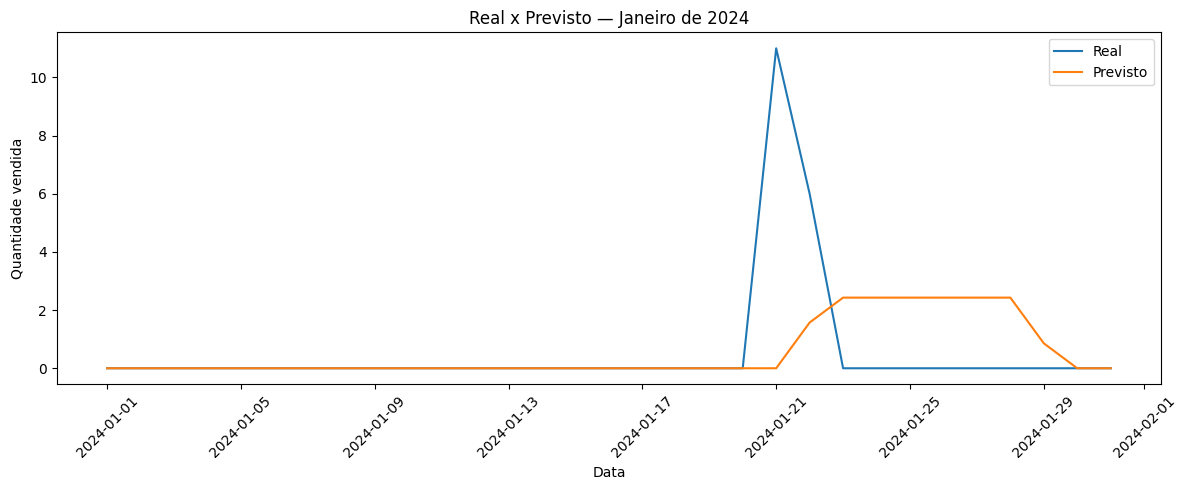

In [0]:
# Gráfico simples comparando valores reais e previstos no período de teste
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test["sale_date"], test["quantity"], label="Real")
plt.plot(test["sale_date"], test["forecast"], label="Previsto")
plt.title("Real x Previsto — Janeiro de 2024")
plt.xlabel("Data")
plt.ylabel("Quantidade vendida")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
%sql
SHOW TABLES IN lh_nautical.04_gold;

database,tableName,isTemporary
`04_gold`,dim_cliente,false
`04_gold`,dim_data,false
`04_gold`,dim_produto,false
`04_gold`,fct_prejuizo_produto,false
`04_gold`,fct_vendas,false
`04_gold`,mart_categoria_top10_clientes,false
`04_gold`,mart_clientes_fieis,false


In [0]:
# Últimos 15 dias do treino
train.tail(15)

,sale_date,quantity
341,2023-12-17,0.0
342,2023-12-18,0.0
343,2023-12-19,0.0
344,2023-12-20,9.0
345,2023-12-21,0.0
346,2023-12-22,0.0
347,2023-12-23,0.0
348,2023-12-24,0.0
349,2023-12-25,0.0
350,2023-12-26,0.0


In [0]:
# Ver os últimos dias antes de 2024
df_serie[df_serie["sale_date"] >= "2023-12-20"]

,sale_date,quantity,forecast
344,2023-12-20,9.0,0.857143
345,2023-12-21,0.0,2.142857
346,2023-12-22,0.0,1.285714
347,2023-12-23,0.0,1.285714
348,2023-12-24,0.0,1.285714
...,...,...,...
683,2024-11-23,0.0,0.000000
684,2024-11-24,16.0,0.000000
685,2024-11-25,0.0,2.285714
686,2024-11-26,0.0,2.285714
